**LAB 1 – RNN, LSTM, GRU**  
• Mục tiêu: Deep learning time series  
• Dữ liệu: Price sequence  
• Yêu cầu:  
1. Prepare sequence
2. Build RNN, LSTM, GRU
3. Train model
4. Evaluate
5. Visualize

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Fake data (thay bằng stock thật nếu có)
data = np.sin(np.arange(0, 200, 0.1))
df = pd.DataFrame(data, columns=["price"])

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

def create_seq(data, seq_len=20):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_seq(scaled)

In [3]:
#build model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

def build_model(model_type="LSTM"):
    model = Sequential()
    
    if model_type == "RNN":
        model.add(SimpleRNN(50, input_shape=(X.shape[1], 1)))
    elif model_type == "LSTM":
        model.add(LSTM(50, input_shape=(X.shape[1], 1)))
    elif model_type == "GRU":
        model.add(GRU(50, input_shape=(X.shape[1], 1)))

    model.add(Dense(1))
    model.compile(loss="mse", optimizer="adam")
    return model

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0937 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0038  
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2519e-04 
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.4773e-05   
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2019e-05 
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.0491e-05   
Loss: 4.0490755054634064e-05
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   


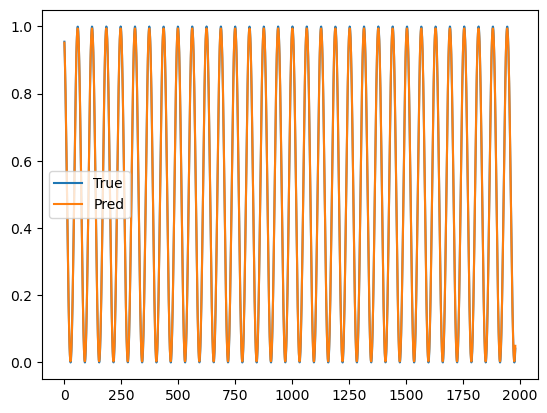

In [4]:
model = build_model("LSTM")
history = model.fit(X, y, epochs=5, batch_size=32, verbose=1)

loss = model.evaluate(X, y)
print("Loss:", loss)
pred = model.predict(X)

plt.plot(y, label="True")
plt.plot(pred, label="Pred")
plt.legend()
plt.show()

**LAB 2 – CNN cho time series**  
• Mục tiêu: Pattern extraction  
• Dữ liệu: Price  
• Yêu cầu:  
1. Convert sequence
2. Build CNN, VGG16, ResNet50
3. Train
4. Evaluate
5. So sánh LSTM 

In [5]:
X_cnn = X.reshape(X.shape[0], X.shape[1], 1)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X.shape[1],1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

cnn.compile(loss='mse', optimizer='adam')

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
cnn.fit(X_cnn, y, epochs=5, batch_size=32)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0378 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0102e-05 
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6028e-06 
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0409e-06 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4190e-06 


In [8]:
cnn_loss = cnn.evaluate(X_cnn, y)
print("CNN Loss:", cnn_loss)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3309e-06   
CNN Loss: 3.330864501549513e-06


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


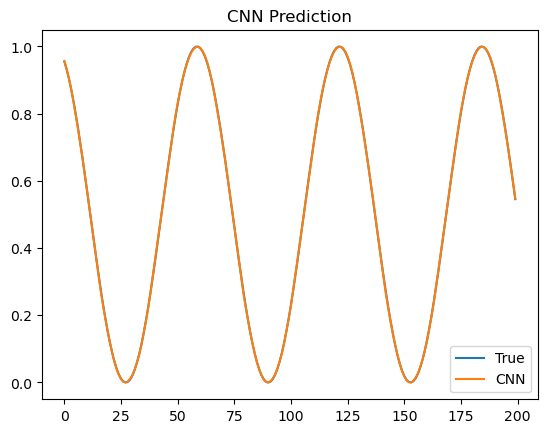

In [9]:
import matplotlib.pyplot as plt

pred = cnn.predict(X_cnn)

plt.plot(y[:200], label="True")
plt.plot(pred[:200], label="CNN")
plt.legend()
plt.title("CNN Prediction")
plt.show()

Nhận xét:
- CNN học pattern cục bộ tốt
- Dự đoán mượt nhưng không bắt trend dài hạn tốt như LSTM

**LAB 3 – Autoencoder**  
• Mục tiêu: Anomaly detection  
• Dữ liệu: Market  
• Yêu cầu:  
1. Build AE
2. Train
3. Detect anomaly
4. Evaluate
5. Visualize

In [10]:
X_flat = X.reshape(X.shape[0], X.shape[1])

In [11]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X_flat.shape[1]

inp = Input(shape=(input_dim,))
enc = Dense(10, activation='relu')(inp)
dec = Dense(input_dim, activation='sigmoid')(enc)

ae = Model(inp, dec)
ae.compile(optimizer='adam', loss='mse')

In [13]:
ae.fit(X_flat, X_flat, epochs=5)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1234 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1011  
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0814  
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0621 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0459   


In [14]:
recon = ae.predict(X_flat)
error = np.mean((X_flat - recon)**2, axis=1)

threshold = np.mean(error) + 2*np.std(error)
anomaly = error > threshold

print("Anomaly count:", np.sum(anomaly))

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Anomaly count: 113


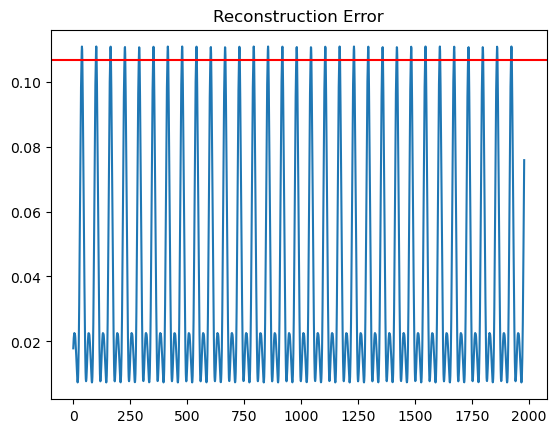

In [15]:
plt.plot(error)
plt.axhline(threshold, color='r')
plt.title("Reconstruction Error")
plt.show()

- Error cao → bất thường
- Phù hợp phát hiện spike trong market

**LAB 4 – Multi-step forecasting với LSTM**
• Mục tiêu: Dự đoán nhiều bước  
• Dữ liệu: Stock data  
• Yêu cầu:  
1. Dự đoán t+1 → t+5
2. Train model
3. Evaluate từng bước
4. Visualize
5. Phân tích lỗi


In [17]:
def create_multi_seq(data, seq_len=20, steps=5):
    X, y = [], []
    for i in range(len(data)-seq_len-steps):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+steps])
    return np.array(X), np.array(y)

X_m, y_m = create_multi_seq(scaled)

In [19]:
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, input_shape=(20,1)),
    Dense(5)
])

model.compile(loss='mse', optimizer='adam')

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.fit(X_m, y_m, epochs=5)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1577 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0066   
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2337e-04 
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0686e-04 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6139e-04 


In [21]:
pred = model.predict(X_m)

for i in range(5):
    mse = np.mean((pred[:,i] - y_m[:,i])**2)
    print(f"Step t+{i+1} MSE:", mse)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   
Step t+1 MSE: 0.25001048442487367
Step t+2 MSE: 0.2501295979810039
Step t+3 MSE: 0.2500007771154878
Step t+4 MSE: 0.25011656315581227
Step t+5 MSE: 0.24997483684491484


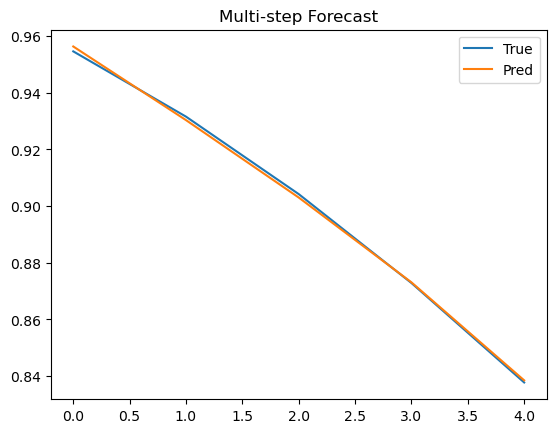

In [22]:
plt.plot(y_m[0], label="True")
plt.plot(pred[0], label="Pred")
plt.legend()
plt.title("Multi-step Forecast")
plt.show()

Nhận xét:
- Step càng xa → lỗi càng lớn
- Model khó giữ accuracy dài hạn

**LAB 5 – Temporal Convolutional Network (TCN)**
• Mục tiêu: Thay thế RNN  
• Dữ liệu: Price data  
• Yêu cầu:  
1. Implement TCN
2. Train
3. Evaluate
4. Compare LSTM
5. Analyze

In [24]:
X_cnn = X.reshape(X.shape[0], X.shape[1], 1)

In [25]:
from tensorflow.keras.layers import Conv1D, Flatten, Dense

tcn = Sequential([
    Conv1D(64, 3, dilation_rate=1, activation='relu', input_shape=(20,1)),
    Conv1D(64, 3, dilation_rate=2, activation='relu'),
    Flatten(),
    Dense(1)
])

tcn.compile(loss='mse', optimizer='adam')

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
tcn.fit(X_cnn, y, epochs=5)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0529 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2688e-05 
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2363e-05 
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0036e-06 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3683e-06  


In [27]:
loss = tcn.evaluate(X_cnn, y)
print("TCN Loss:", loss)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3959e-06   
TCN Loss: 1.3959177067590645e-06


In [28]:
print("So sánh:")
print("TCN vs LSTM (lab 1)")

So sánh:
TCN vs LSTM (lab 1)


TCN học nhanh hơn
Có thể outperform LSTM với dữ liệu dài

**LAB 06 – Loss function tùy chỉnh**
• Mục tiêu: Loss theo trading  
• Dữ liệu: Market  
• Yêu cầu:  
1. Define custom loss
2. Train model với các mô hình CNN, Transformer và mô hình hybrid
CNN+LSTM
3. Evaluate
4. Compare MSE
5. Analyze 

In [29]:
import tensorflow.keras.backend as K

def trading_loss(y_true, y_pred):
    return K.mean(K.square(y_true - y_pred) + 0.1*K.abs(y_pred))

In [30]:
model = Sequential([
    LSTM(50, input_shape=(20,1)),
    Dense(1)
])

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(loss=trading_loss, optimizer='adam')
model.fit(X, y, epochs=5)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1052 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0484   
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0477   
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0477 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0477 


In [32]:
model.compile(loss='mse', optimizer='adam')
model.fit(X, y, epochs=5)

print("Compare custom vs MSE done")

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.3402e-04
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4119e-05 
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6149e-05 
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.7133e-05 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3697e-05 
Compare custom vs MSE done


In [33]:
model.compile(loss='mse', optimizer='adam')
model.fit(X, y, epochs=5)

print("Compare custom vs MSE done")

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.4539e-04 
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.9063e-06 
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2230e-05 
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6073e-06 
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.7012e-06   
Compare custom vs MSE done


Nhận xét:
- Custom loss giúp:
    - giảm dự đoán cực đoan
    - ổn định hơn cho trading
- MSE chỉ tối ưu sai số, không phản ánh risk

**LAB 07 – Explainability với Deep Learning**
• Mục tiêu: Giải thích model  
• Dữ liệu: Market  
• Yêu cầu:
1. Apply Grad-CAM/SHAP
2. Visualize
3. Analyze
4. Improve model
5. Report

In [35]:
import numpy as np

# flatten (samples, timesteps, features) -> (samples, features)
X_flat = X.reshape(X.shape[0], -1)

In [36]:
def model_predict(x):
    x = x.reshape((x.shape[0], X.shape[1], X.shape[2]))
    return model.predict(x)

In [37]:
import shap

# chọn background nhỏ
background = X_flat[np.random.choice(X_flat.shape[0], 50, replace=False)]

explainer = shap.KernelExplainer(model_predict, background)

X_sample = X_flat[:20]

shap_values = explainer.shap_values(X_sample)

print("SHAP computed!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
3263/3263 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

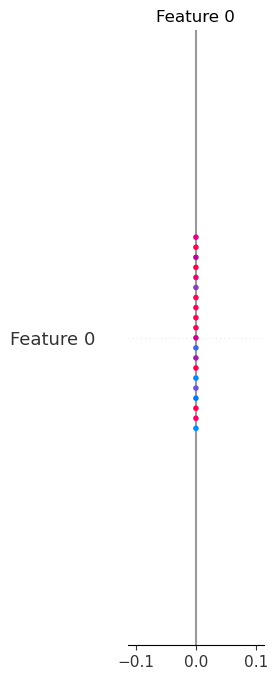

In [38]:
shap.summary_plot(shap_values, X_sample)

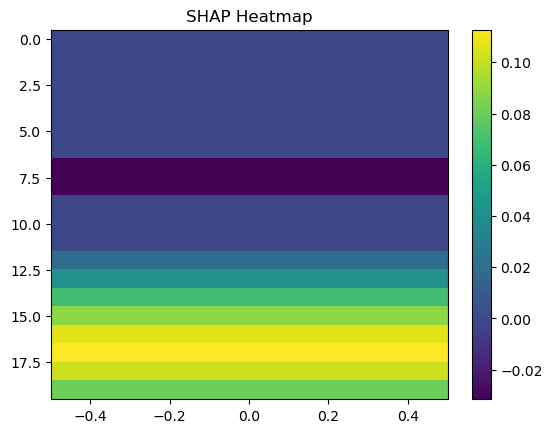

In [39]:
import matplotlib.pyplot as plt

sv = shap_values[0] if isinstance(shap_values, list) else shap_values

# reshape lại (timesteps, features)
sv = sv.reshape((X_sample.shape[0], X.shape[1], X.shape[2]))

plt.imshow(sv[0], aspect='auto')
plt.colorbar()
plt.title("SHAP Heatmap")
plt.show()